In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
#Load Dataset
df = pd.read_csv(r"C:\Users\kavya choubey\OneDrive\Desktop\Hospital Analytics Project\Dataset\healthcare_patient_analytics.csv.csv")

In [9]:
#Create the ML dataframe
ml_df = df.copy()

In [10]:
#Import ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.ensemble import RandomForestClassifier

In [11]:
#Encode Categorical Columns
encoder = LabelEncoder()

categorical_columns = [
    'age_group',
    'gender',
    'region',
    'department',
    'treatment_type',
    'visit_type'
]

for column in categorical_columns:
    ml_df[column] = encoder.fit_transform(ml_df[column])

In [22]:
#Prepare Target Variable
ml_df['RiskCategory'] = pd.qcut(
    ml_df['readmission_risk'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

Risk < 0.33  → Low

0.33–0.66 → Medium

>0.66 → High

In [24]:
#Encode Target
target_encoder = LabelEncoder()

ml_df['RiskCategory'] = target_encoder.fit_transform(
    ml_df['RiskCategory']
)

In [25]:
#Select Features
X = ml_df[
[
'age_group',
'gender',
'region',
'department',
'treatment_type',
'visit_type',
'length_of_stay_days',
'treatment_cost',
'recovery_score'
]
]

y = ml_df['RiskCategory']

In [26]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [27]:
#Train Model
model = RandomForestClassifier(random_state=42)

model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
#Prediction
prediction = model.predict(X_test)

In [29]:
#Accuracy
accuracy = accuracy_score(y_test,prediction)

print("Accuracy :",accuracy)

Accuracy : 0.319


In [30]:
#Classification Report
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       0.30      0.28      0.29       313
           1       0.32      0.32      0.32       339
           2       0.34      0.35      0.34       348

    accuracy                           0.32      1000
   macro avg       0.32      0.32      0.32      1000
weighted avg       0.32      0.32      0.32      1000



In [31]:
#Confusion Matrix
cm = confusion_matrix(y_test,prediction)

cm

array([[ 88, 110, 115],
       [108, 110, 121],
       [100, 127, 121]])

In [32]:
#Feature Importance
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
7,treatment_cost,0.241705
6,length_of_stay_days,0.203744
8,recovery_score,0.198395
3,department,0.077557
4,treatment_type,0.076319
0,age_group,0.071317
2,region,0.067087
1,gender,0.032638
5,visit_type,0.031238


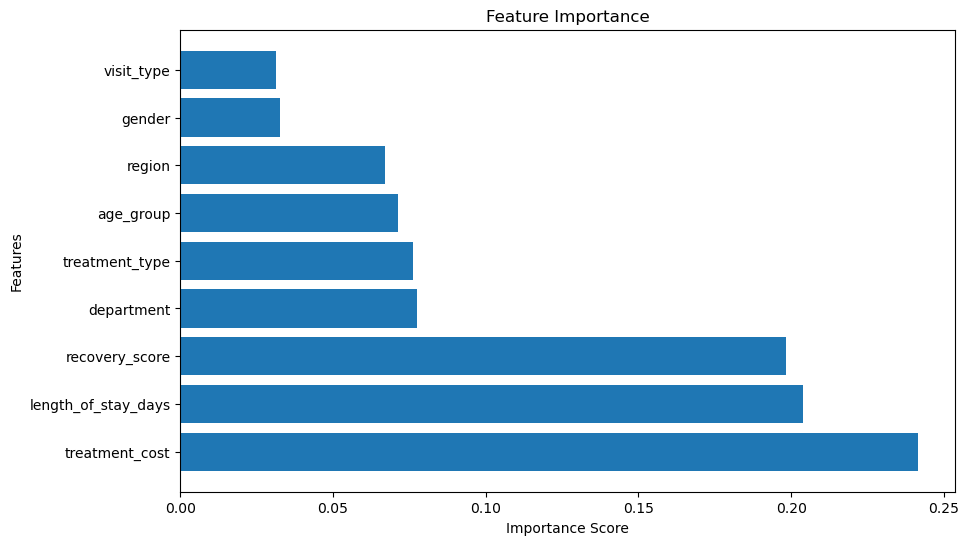

In [33]:
#Plot Feature Importance
plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

Business Problem

Predict which patients are at a higher risk of readmission so that hospitals can take preventive action.

Model Used

Random Forest Classifier

Evaluation
Accuracy Score
Classification Report
Confusion Matrix
Key Findings
Identify the most influential factors affecting readmission risk.
Help healthcare providers prioritize follow-up care for high-risk patients.
Support better resource allocation and improve patient outcomes.